fantasy_points_ppr       1.000000
def_rank_w               0.105071
def_pts_allowed_last5    0.102807
Name: fantasy_points_ppr, dtype: float64


C:\Users\mc669\AppData\Local\Temp\ipykernel_22568\3012427693.py:78: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[7. 6. 3. ... 4. 1. 4.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  def_stats.loc[def_stats['def_rank'] <= 7, 'def_rank_w'] = \


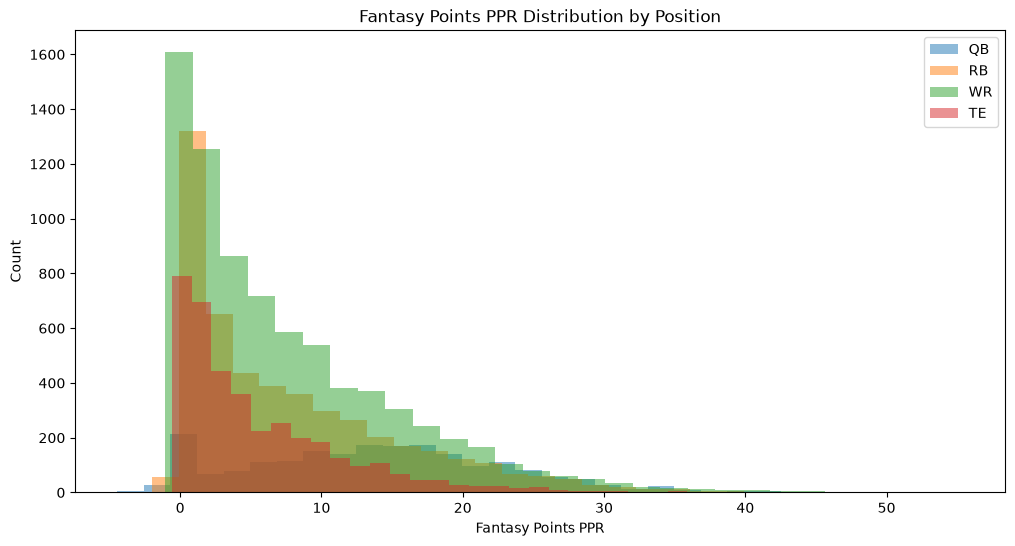

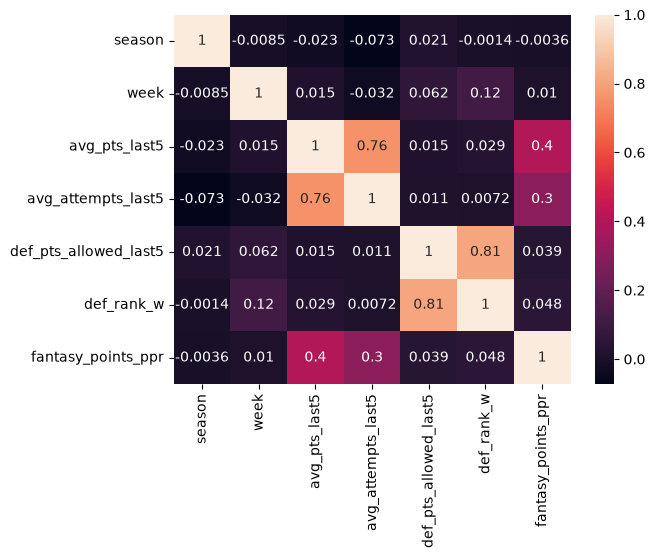

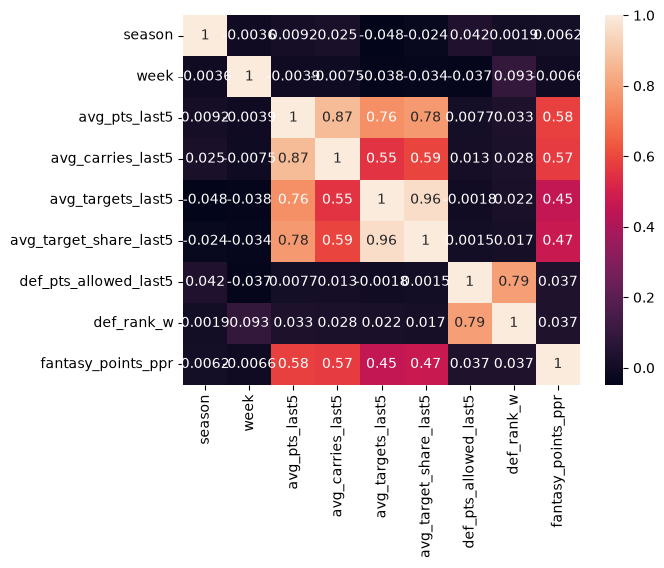

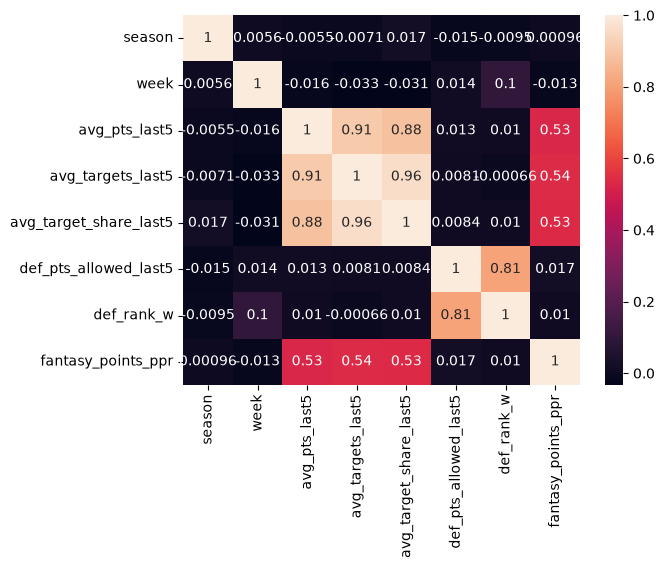

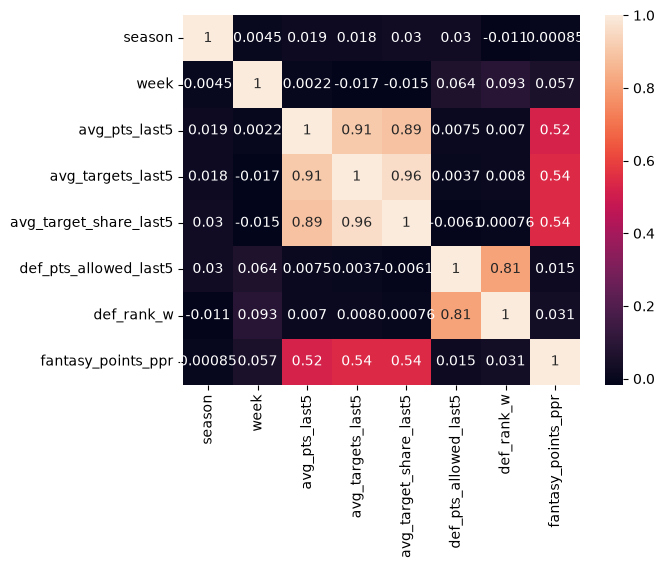

In [149]:
# %pip install nflreadpy
# %pip install pyarrow

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import nflreadpy as nfl
from IPython.display import display

# for data relevancy (and size) only select most recent 3 seasons
seasons = [2022, 2023, 2024]
# collect player stats/data
df = nfl.load_player_stats(seasons=seasons).to_pandas()
# address NaNs
df = df.dropna(subset=['player_name'])

### PLAYER ROLLING AVERAGES
# sort for rolling calcs
df = df.sort_values(['player_name', 'season', 'week']).reset_index(drop=True)

# rolling 5 across season boundaries
df['avg_pts_last5'] = df.groupby('player_name')['fantasy_points_ppr'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

df['avg_attempts_last5'] = df.groupby('player_name')['attempts'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

df['avg_carries_last5'] = df.groupby('player_name')['carries'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

df['avg_targets_last5'] = df.groupby('player_name')['targets'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

df['avg_target_share_last5'] = df.groupby('player_name')['target_share'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

### DEFENSIVE TEAM STATS
# calculate position specific yards and tds allowed per defense per week
def_stats = df.groupby(['opponent_team', 'position', 'season', 'week']).agg(
    pass_yds=('passing_yards', 'sum'),
    rush_yds=('rushing_yards', 'sum'),
    rec_yds=('receiving_yards', 'sum'),
    pass_tds=('passing_tds', 'sum'),
    rush_tds=('rushing_tds', 'sum'),
    rec_tds=('receiving_tds', 'sum')
).reset_index()

# calculate composite fantasy points allowed per position
# QBs => passing yards + passing tds weighted
def_stats.loc[def_stats['position'] == 'QB', 'def_pts_allowed'] = \
    (def_stats['pass_yds'] * 0.04) + (def_stats['pass_tds'] * 6)

# RBs => rushing yards + rushing tds weighted
def_stats.loc[def_stats['position'] == 'RB', 'def_pts_allowed'] = \
    (def_stats['rush_yds'] * 0.1) + (def_stats['rush_tds'] * 6)

# WR/TE => receiving yards + receiving tds weighted
def_stats.loc[def_stats['position'].isin(['WR', 'TE']), 'def_pts_allowed'] = \
    (def_stats['rec_yds'] * 0.1) + (def_stats['rec_tds'] * 6)

# rolling 5 game average across season boundaries
def_stats = def_stats.sort_values(['opponent_team', 'position', 'season', 'week'])
def_stats['def_pts_allowed_last5'] = def_stats.groupby(['opponent_team', 'position'])['def_pts_allowed'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

# DEF RANKS WEIGHTED
# TOP and BOTTOM 7
def_stats['def_rank'] = def_stats.groupby(['position', 'season', 'week'])['def_pts_allowed_last5'].rank(ascending=False)
def_stats['def_rank_w'] = 0
# rank 1 = easiest (most pts allowed) = positive 7
def_stats.loc[def_stats['def_rank'] <= 7, 'def_rank_w'] = \
    (8 - def_stats.loc[def_stats['def_rank'] <= 7, 'def_rank'])
# rank 32 = toughest (fewest pts allowed) = negative 7
def_stats.loc[def_stats['def_rank'] >= 26, 'def_rank_w'] = \
    (25 - def_stats.loc[def_stats['def_rank'] >= 26, 'def_rank'])

# merge back into df
df = df.merge(def_stats[['opponent_team', 'position', 'season', 'week', 'def_pts_allowed_last5', 'def_rank_w']],
              on=['opponent_team', 'position', 'season', 'week'], how='left')

# check correlation
print(df[['def_pts_allowed_last5', 'def_rank_w', 'fantasy_points_ppr']].corr()['fantasy_points_ppr'].sort_values(ascending=False))

### SPLIT BY POSITION
qb_df = df[df['position'] == 'QB'][[
    'player_name', 'team', 'season', 'week', 'season_type', 'opponent_team',
    'avg_pts_last5', 'avg_attempts_last5',
    'def_pts_allowed_last5', 'def_rank_w',
    'fantasy_points_ppr'
]].copy()

rb_df = df[df['position'] == 'RB'][[
    'player_name', 'team', 'season', 'week', 'season_type', 'opponent_team',
    'avg_pts_last5', 'avg_carries_last5', 'avg_targets_last5', 'avg_target_share_last5',
    'def_pts_allowed_last5', 'def_rank_w',
    'fantasy_points_ppr'
]].copy()

wr_df = df[df['position'] == 'WR'][[
    'player_name', 'team', 'season', 'week', 'season_type', 'opponent_team',
    'avg_pts_last5', 'avg_targets_last5', 'avg_target_share_last5',
    'def_pts_allowed_last5', 'def_rank_w',
    'fantasy_points_ppr'
]].copy()

te_df = df[df['position'] == 'TE'][[
    'player_name', 'team', 'season', 'week', 'season_type', 'opponent_team',
    'avg_pts_last5', 'avg_targets_last5', 'avg_target_share_last5',
    'def_pts_allowed_last5', 'def_rank_w',
    'fantasy_points_ppr'
]].copy()

### VISUALIZE
fig, ax = plt.subplots(figsize=(12, 6))

qb_df['fantasy_points_ppr'].plot(kind='hist', ax=ax, bins=30, alpha=0.5, label='QB')
rb_df['fantasy_points_ppr'].plot(kind='hist', ax=ax, bins=30, alpha=0.5, label='RB')
wr_df['fantasy_points_ppr'].plot(kind='hist', ax=ax, bins=30, alpha=0.5, label='WR')
te_df['fantasy_points_ppr'].plot(kind='hist', ax=ax, bins=30, alpha=0.5, label='TE')

ax.set_title('Fantasy Points PPR Distribution by Position')
ax.set_xlabel('Fantasy Points PPR')
ax.set_ylabel('Count')
ax.legend()
plt.show()

# in a vaccuum how does each feature do
# print(df[['is_home', 'fantasy_points_ppr']].corr())

# correlation plot
corr = qb_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.show()

corr = rb_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.show()

corr = wr_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.show()

corr = te_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.show()


# Schedule Data (Weather, Setting, Home/Away)

```
# need more contextual data about the game
# load schedules data which has game conditions
sched = nfl.load_schedules().to_pandas()
sched = sched[['game_id', 'home_team', 'away_team', 'roof', 'surface', 'temp', 'wind']]

# merge using game_id since we already have it
df = df.merge(sched, on='game_id', how='left')

df['is_home'] = (df['team'].values == df['home_team']).astype(int)
df['is_dome'] = df['roof'].isin(['dome', 'closed']).astype(int)
df['is_grass'] = (df['surface'] == 'grass').astype(int)

# address NaNs
df.loc[df['roof'].isin(['dome', 'closed']), 'temp'] = df['temp'].fillna(70)
df.loc[df['roof'].isin(['dome', 'closed', 'open']), 'wind'] = df['wind'].fillna(0)
```

After visualizing this data with our output, the correlation plot didn't show favorable values. Instead of many values in the roof and surface features, I thought that simplifying the variable might help by creating is_dome and is_grass. Grass is known as the wide player favorite to play on and the dome offers football unimpeded by the elements, however these values changed slightly, they were still too small to include. Before removing the data entirely, I dedcided to try out the fantasy football home field advantage, which turned out to be nearly non-existent. After confirming that the data here would not be useful to training a model, I removed the data and moved on.



# Injury Data
```
inj = nfl.load_injuries(seasons=seasons).to_pandas()

# injury impact mapping
high_impact = ['Knee', 'Ankle', 'Hamstring', 'Foot', 'Hip', 'Quad', 'Calf', 'Thigh', 'Achilles', 'Concussion', 'Head', 'Ribs', 'Back', 'Neck']
low_impact  = ['Shoulder', 'Elbow', 'Wrist', 'Hand', 'Thumb', 'Finger', 'Chest', 'Bicep', 'Tricep']
# helper func to encode inj impact
def get_inj_impact(injury):
    if pd.isna(injury):
        return 0
    injury = str(injury)
    if any(body_part in injury for body_part in high_impact):
        return 2
    elif any(body_part in injury for body_part in low_impact):
        return 1
    return 0

# encode prac and report inj impact
inj['inj_report_impact'] = inj['report_primary_injury'].apply(get_inj_impact)
inj['inj_prac_impact'] = inj['practice_primary_injury'].apply(get_inj_impact)

# encode report status
status_map = {
    'Out': 0,
    'Doubtful': 1,
    'Questionable': 2
}
inj['report_status_enc'] = inj['report_status'].map(status_map).fillna(3)

# encode practice status
practice_map = {
    'Did Not Participate In Practice': 0,
    'Limited Participation in Practice': 1,
    'Full Participation in Practice': 2
}
inj['practice_status_enc'] = inj['practice_status'].map(practice_map).fillna(2)

# cut to what we need
inj = inj[['gsis_id', 'full_name', 'team', 'season', 'week', 
                      'report_status_enc', 'practice_status_enc',
                      'inj_report_impact', 'inj_prac_impact']]

# merge inj with df
df = df.merge(inj[['gsis_id', 'season', 'week', 'report_status_enc', 'practice_status_enc', 'inj_report_impact', 'inj_prac_impact']], 
              left_on=['player_id', 'season', 'week'],
              right_on=['gsis_id', 'season', 'week'],
              how='left')

# players not in injury report are healthy
df['report_status_enc'] = df['report_status_enc'].fillna(3)
df['practice_status_enc'] = df['practice_status_enc'].fillna(2)
df['inj_report_impact'] = df['inj_report_impact'].fillna(0)
df['inj_prac_impact'] = df['inj_prac_impact'].fillna(0)
```

A huge indicator of a players performance is their health, however after exploring this data, I found that there was only 2000/54000 rows that merged. After some research, I learned that if the player is Out, there is no row in the fantasy player stats table. The corr value (0.04ish) for these injury features were actually pretty strong considering there was only 2000 values. I was hoping that this would reduce the amount of 0s in the dataset by explaining them with this data addition. However, that wasn't the case and since the data only explained 4% of the data, it wasn't worth keeping.

# Defensive Ranks Weighted

```
### WEIGHTED EXPERIMENT
#  --- TEST 1: rank 1 - 32
def_stats['def_rank'] = def_stats.groupby(['position', 'season', 'week'])['def_pts_allowed_last5'].rank(ascending=False)

# --- TEST 2: binary tiers (-2, 0, 2) ---
def_stats['def_tier_binary'] = 0
def_stats.loc[def_stats['def_rank'] <= 7, 'def_tier_binary'] = -2   # tough matchup
def_stats.loc[def_stats['def_rank'] >= 26, 'def_tier_binary'] = 2   # easy matchup

# --- TEST 3: scaled tiers (1-7) ---
def_stats['def_rank_w'] = 0
# rank 1 = easiest (most pts allowed) = positive 7
def_stats.loc[def_stats['def_rank'] <= 7, 'def_rank_w'] = \
    (8 - def_stats.loc[def_stats['def_rank'] <= 7, 'def_rank'])
# rank 32 = toughest (fewest pts allowed) = negative 7
def_stats.loc[def_stats['def_rank'] >= 26, 'def_rank_w'] = \
    (25 - def_stats.loc[def_stats['def_rank'] >= 26, 'def_rank'])
```

## Output
- fantasy_points_ppr       1.000000
- def_rank_w               0.105071
- def_pts_allowed_last5    0.102807
- def_rank                -0.030399
- def_tier_binary         -0.096029

In my own experience, when a player faces a tough defense they score less points, and vice versa. Usually, this only really applies to the elite top/bottom 5 or so defenses. With this experiment, I was able to run a series of tests to prove that hypothesis. I wanted to compare these three methods against each other. In the output, you can see that the ranked weights worked the best out of these methods by limiting the noise of the inner 18 teams. Once these features were added to the positions, they become much weaker in correlation. I'm exploring other ways to weight or manipulate these values to see if the signal will increase.